# Этап 1: Разведочный анализ данных блокчейна (EDA)

## Описание файла
Данный скрипт выполняет первичный разведочный анализ (Exploratory Data Analysis) сырого среза транзакций сети Bitcoin, полученных через JSON-RPC API узла Bitcoin Core. 

**Цели данного этапа:**
1. Проверка целостности и структуры собранного набора данных.
2. Вычисление базовых статистик сети (количество уникальных адресов, распределение входов и выходов).
3. Первичный поиск транзакций с множественными входами (Multi-input) для подтверждения применимости графовых эвристик на следующих этапах работы.

**Входные данные:** `../data/blockchain_dataset.csv`

Датасет загружен!
Размер: 5,214 строк × 6 столбцов
Уникальных блоков: 6
Уникальных транзакций: 675
Уникальных адресов: 1,417
Типы записей:
Type
INPUT       3778
OUTPUT      1430
COINBASE       6
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   BlockHeight  5214 non-null   int64  
 1   Time         5214 non-null   object 
 2   TxID         5214 non-null   object 
 3   Type         5214 non-null   object 
 4   Address      5214 non-null   object 
 5   Amount_BTC   5214 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 244.5+ KB
INPUT адресов: 928
OUTPUT адресов: 758
COINBASE: 1
Транзакций с 2+ INPUT: 257
Максимум INPUT в одной tx: 488

Топ-5 tx по количеству INPUT:
TxID
f412b81ce6af48d7068f5837be02872eec970cd09cb44647255fd8d1fd559315    488
717fc1ae58f5e7e3c3196a71d83ff467e5731a1bf5a4dc2108976e29

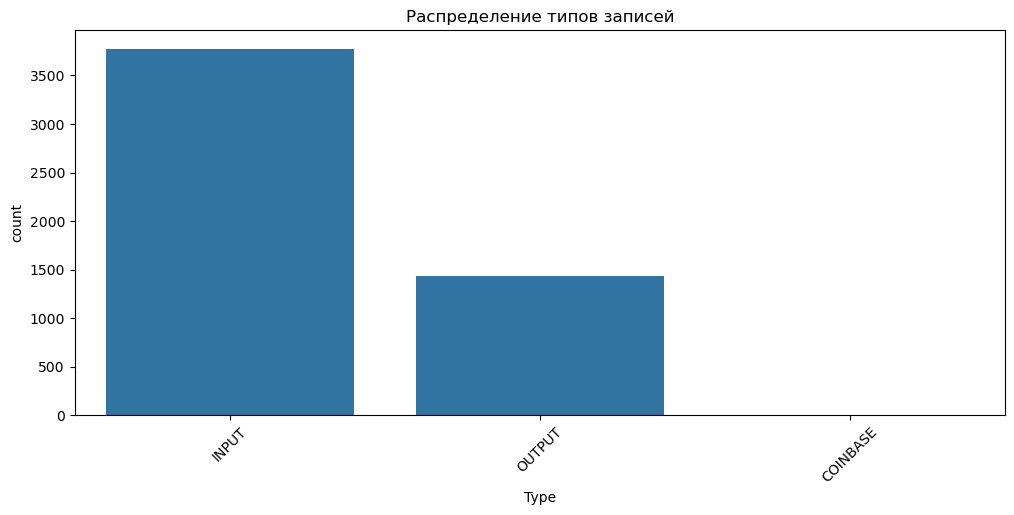

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('blockchain_dataset.csv')

print("Датасет загружен!")
print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f"Уникальных блоков: {df['BlockHeight'].nunique()}")
print(f"Уникальных транзакций: {df['TxID'].nunique():,}")
print(f"Уникальных адресов: {df['Address'].nunique():,}")
print(f"Типы записей:\n{df['Type'].value_counts()}")

df.info()
df.describe()

input_addrs = df[df['Type'] == 'INPUT']['Address'].nunique()
output_addrs = df[df['Type'] == 'OUTPUT']['Address'].nunique()
coinbase = df[df['Type'] == 'COINBASE']['Address'].nunique()

print(f"INPUT адресов: {input_addrs:,}")
print(f"OUTPUT адресов: {output_addrs:,}")
print(f"COINBASE: {coinbase}")

multi_input_txs = df[df['Type'] == 'INPUT'].groupby('TxID').size()
multi_input_txs = multi_input_txs[multi_input_txs > 1]

print(f"Транзакций с 2+ INPUT: {len(multi_input_txs):,}")
print(f"Максимум INPUT в одной tx: {multi_input_txs.max()}")
print("\nТоп-5 tx по количеству INPUT:")
print(multi_input_txs.sort_values(ascending=False).head())

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Type', order=df['Type'].value_counts().index)
plt.title('Распределение типов записей')
plt.xticks(rotation=45)
plt.show()

df.to_csv('df_clean.csv', index=False)

In [2]:
import pandas as pd
import networkx as nx

def build_clusters(csv_path):
    print("1. Загрузка данных...")
    df = pd.read_csv(csv_path)
    
    inputs_df = df[(df['Type'] == 'INPUT') & (df['Address'] != 'New_Coins')].copy()
    
    print("2. Поиск транзакций с несколькими входами (Multi-input)...")
    tx_groups = inputs_df.groupby('TxID')['Address'].apply(list)
    
    multi_input_txs = tx_groups[tx_groups.apply(len) > 1]
    print(f"Найдено транзакций для связывания: {len(multi_input_txs)}")
    
    print("3. Построение графа связей...")
    G = nx.Graph()
    
    for addresses in multi_input_txs:
        base_address = addresses[0]
        for addr in addresses[1:]:
            G.add_edge(base_address, addr)
            
    print("4. Поиск кластеров (компонент связности)...")
    clusters = list(nx.connected_components(G))
    print(f"Всего найдено кластеров (сущностей): {len(clusters)}")
    
    address_to_cluster = {}
    for cluster_id, nodes in enumerate(clusters):
        for node in nodes:
            address_to_cluster[node] = f"Cluster_{cluster_id}"
            
    all_unique_addresses = df[df['Address'] != 'New_Coins']['Address'].unique()
    current_cluster_id = len(clusters)
    
    for addr in all_unique_addresses:
        if addr not in address_to_cluster and addr != "Non-standard":
            address_to_cluster[addr] = f"Cluster_{current_cluster_id}"
            current_cluster_id += 1
            
    print("5. Применение кластеров к исходному датасету...")
    df['Entity_ID'] = df['Address'].map(address_to_cluster)
    
    output_file = "blockchain_clustered.csv"
    df.to_csv(output_file, index=False)
    print(f"Готово! Данные сохранены в {output_file}")
    
    return df

if __name__ == "__main__":
    df_clustered = build_clusters("blockchain_dataset.csv")
    
    print("\nТоп-5 самых крупных кластеров:")
    cluster_sizes = df_clustered.groupby('Entity_ID')['Address'].nunique().sort_values(ascending=False)
    print(cluster_sizes.head())

1. Загрузка данных...
2. Поиск транзакций с несколькими входами (Multi-input)...
Найдено транзакций для связывания: 257
3. Построение графа связей...
4. Поиск кластеров (компонент связности)...
Всего найдено кластеров (сущностей): 100
5. Применение кластеров к исходному датасету...
Готово! Данные сохранены в blockchain_clustered.csv

Топ-5 самых крупных кластеров:
Entity_ID
Cluster_21    318
Cluster_77     33
Cluster_2      30
Cluster_15     22
Cluster_73     17
Name: Address, dtype: int64
